In [5]:
import pandas as pd

columns = [
    "class",
    "cap_shape",
    "cap_surface",
    "cap_color",
    "bruises",
    "odor",
    "gill_attachment",
    "gill_spacing",
    "gill_size",
    "gill_color",
    "stalk_shape",
    "stalk_root",
    "stalk_surface_above_ring",
    "stalk_surface_below_ring",
    "stalk_color_above_ring",
    "stalk_color_below_ring",
    "veil_type",
    "veil_color",
    "ring_number",
    "ring_type",
    "spore_print_color",
    "population",
    "habitat"
]

df = pd.read_csv(
    "agaricus-lepiota.data",
    header=None,
    names=columns
)

# Convert target labels
df["class"] = df["class"].map({
    "e": 0,  # edible
    "p": 1   # poisonous
})

# Save as CSV
df.to_csv("mushroom.csv", index=False)

print(df.head())
print(df.shape)

   class cap_shape cap_surface cap_color bruises odor gill_attachment  \
0      1         x           s         n       t    p               f   
1      0         x           s         y       t    a               f   
2      0         b           s         w       t    l               f   
3      1         x           y         w       t    p               f   
4      0         x           s         g       f    n               f   

  gill_spacing gill_size gill_color  ... stalk_surface_below_ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk_color_above_ring stalk_color_below_ring veil_type veil_color  \
0                      w                      w         p          w   
1 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
dataset = pd.read_csv('mushroom.csv')
dataset.head()
X = dataset.iloc[:, 1:].values
y = dataset.iloc[:, 0].values

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in dataset.columns:
    dataset[col] = le.fit_transform(dataset[col])

X = dataset.iloc[:, 1:].values
y = dataset.iloc[:, 0].values

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [17]:
print(X_train)

[[2 3 9 ... 1 5 1]
 [5 3 4 ... 3 5 1]
 [2 2 3 ... 2 0 1]
 ...
 [5 2 3 ... 3 3 1]
 [2 0 4 ... 3 4 0]
 [5 3 3 ... 3 5 0]]


In [18]:
print(X_test)

[[5 3 4 ... 2 3 5]
 [2 3 3 ... 2 5 0]
 [5 3 9 ... 3 2 3]
 ...
 [5 3 2 ... 7 4 0]
 [5 2 9 ... 2 3 1]
 [3 2 4 ... 0 1 2]]


In [19]:
print(y_train)

[1 0 0 ... 0 0 0]


In [20]:
print(y_test)

[1 0 0 ... 1 0 0]


In [21]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [22]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[1 1]
 [1 0]
 [0 0]
 ...
 [1 1]
 [0 0]
 [0 0]]


In [23]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(y_test,y_pred)
print(cm)
accuracy_score(y_test,y_pred)

[[966  95]
 [ 79 891]]


0.914327917282127

In [24]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.914327917282127

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      1061
           1       0.90      0.92      0.91       970

    accuracy                           0.91      2031
   macro avg       0.91      0.91      0.91      2031
weighted avg       0.91      0.91      0.91      2031



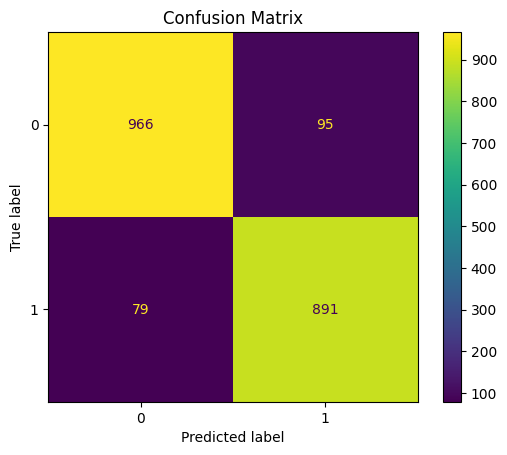

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()